In [174]:
!ls /mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets

combined_metadata.csv  original  region_brain  whole_brain


In [300]:
from preprocessing.load_dataset import SubCorBatDataset
import pandas as pd
import os

### Input data
# Path to dataset
DATA_PATH = "/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/"
load_ds_path = DATA_PATH + "batched_adni/"
# Files to load/save extension
extension = ".npz"
# Pretrained weights for the VAE
ckpt_vae_path = ""#"./data/pretrained_models/autoencoder_puglisi.pth"
# Pretrained weights for the Discriminator
ckpt_dis_path = ""#"./data/pretrained_models/ckpt_dis_.pth"
# Preparing image for using as input of the VAE
target_shape = [1, 160, 224, 160] # Desired shape: [1, 160, 224, 160]

# Load metadata
index_ds = pd.read_csv(os.path.join(DATA_PATH,"original/dataset_index.csv"))
clinical_ds = pd.read_csv(os.path.join(DATA_PATH,"combined_metadata.csv"))
metadata = pd.merge(index_ds, clinical_ds, on="GUID", how="inner") # Merge on the 'GUID' column
print(f"METADATA: Original rows: {len(metadata)}")

# First, ensure empty strings are treated as NaN
metadata['subject'].replace('', pd.NA, inplace=True)

# Then drop rows where subject is NaN
metadata = metadata.dropna(subset=['subject'])

# Optional: reset index
metadata = metadata.reset_index(drop=True)
print(f"METADATA: Remaining rows: {len(metadata)}") # Check result

# Load labels

# Training configuration
batch_files = sorted(metadata["batch_file"].unique())

# Load labels and bounding boxes
labels_df = pd.read_csv("data/labels.csv")
bb_df = pd.read_csv("data/bounding_boxes.csv")
labels_bb_df = pd.merge(labels_df, bb_df, on="LabelName", how="inner") # Merge on the 'GUID' column


METADATA: Original rows: 26685
METADATA: Remaining rows: 26685


In [301]:
metadata.query("project == 'aibl'")

,GUID,dataset,batch_file,index_in_batch,index_global,project,subject,timepoint,scan_type,field_strength,manufacturer,model_name,disease,age,partition
24359,I1055803,AIBL,/mimer/NOBACKUP/groups/naiss2025-23-412/felixn...,0,24359,aibl,670,bl,T1,3.0,SIEMENS,TrioTim,CN,71.0,test
24360,I1055806,AIBL,/mimer/NOBACKUP/groups/naiss2025-23-412/felixn...,1,24360,aibl,33,m72,T1,3.0,SIEMENS,TrioTim,MCI,88.0,test
24361,I1055820,AIBL,/mimer/NOBACKUP/groups/naiss2025-23-412/felixn...,2,24361,aibl,88,m72,T1,3.0,SIEMENS,TrioTim,CN,75.0,test
24362,I1055821,AIBL,/mimer/NOBACKUP/groups/naiss2025-23-412/felixn...,3,24362,aibl,80,m72,T1,3.0,SIEMENS,TrioTim,CN,78.0,test
24363,I1055836,AIBL,/mimer/NOBACKUP/groups/naiss2025-23-412/felixn...,4,24363,aibl,105,m72,T1,3.0,SIEMENS,TrioTim,CN,69.0,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25644,I455233,AIBL,/mimer/NOBACKUP/groups/naiss2025-23-412/felixn...,286,25644,aibl,1368,bl,T1,3.0,SIEMENS,Verio,AD,82.0,test
25645,I455235,AIBL,/mimer/NOBACKUP/groups/naiss2025-23-412/felixn...,287,25645,aibl,1437,bl,T1,3.0,SIEMENS,Verio,AD,72.0,test
25646,I455236,AIBL,/mimer/NOBACKUP/groups/naiss2025-23-412/felixn...,288,25646,aibl,1430,bl,T1,3.0,SIEMENS,Verio,AD,81.0,test
25647,I455237,AIBL,/mimer/NOBACKUP/groups/naiss2025-23-412/felixn...,289,25647,aibl,1384,bl,T1,3.0,SIEMENS,Verio,CN,79.0,test


In [302]:
batch_files = batch_files[-5:-3]
# batch_files = batch_files[-2:]

In [303]:
batch_files

['/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/original/batched_aibl/batch_0001.npz',
 '/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/original/batched_aibl/batch_0002.npz']

In [304]:
from preprocessing.load_dataset import SingleStructDataset

dataset = SingleStructDataset(metadata, batch_files, labels_bb_df, target_struct_name="Left-Hippocampus")

In [305]:
import numpy as np

guids = np.array(dataset.guids)


In [306]:
guids

array(['I450385', 'I164108', 'I473670', ..., 'I1111827', 'I1078846',
       'I1111773'], dtype='<U8')

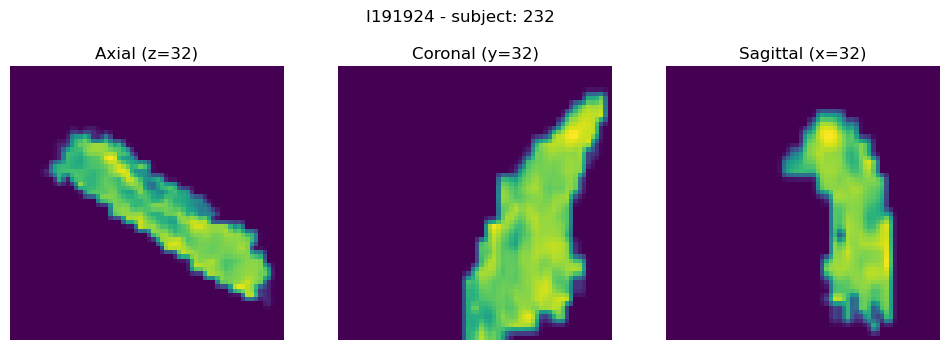

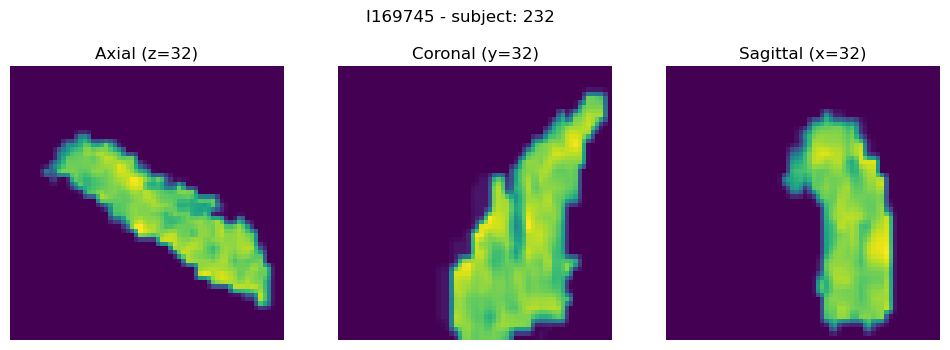

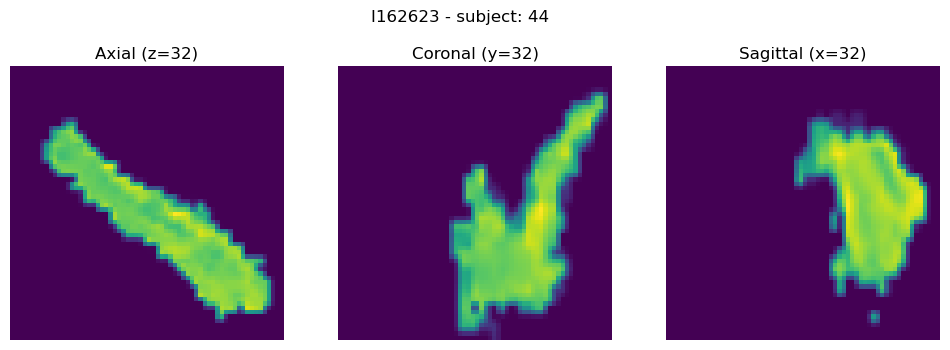

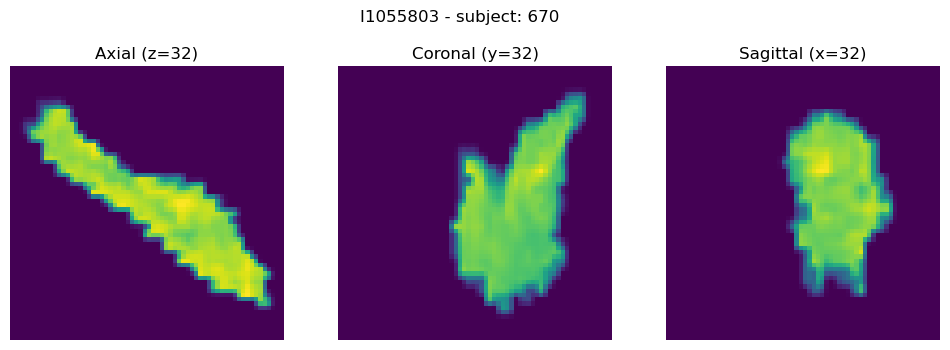

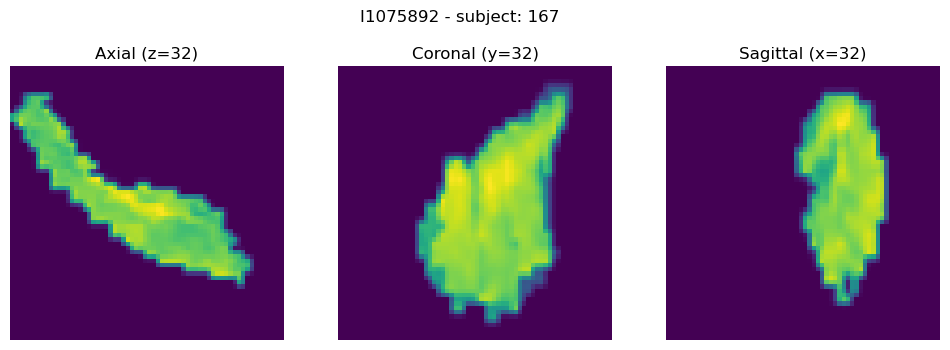

In [321]:
import matplotlib.pyplot as plt
import torch

%matplotlib inline

i_subs = [np.where(guids == "I191924")[0][0],
          np.where(guids == "I169745")[0][0],
          np.where(guids == "I162623")[0][0],
          np.where(guids == "I1055803")[0][0],
          np.where(guids == "I1075892")[0][0]
          ]

# i_subs = [np.where(guids == "slim_25632_1")[0][0],
#           np.where(guids == "slim_25632_2")[0][0],
#           np.where(guids == "slim_25632_3")[0][0]
#           ]


# i_subs = [9,10,11,12]

for i_sub in i_subs:
    sample = dataset[i_sub]
    struct = sample["image"][0]  # shape [D, H, W]

    # --- Axial (Z axis) ---
    z_profile = struct.sum(axis=(1, 2))
    z_max = torch.argmax(z_profile).item()
    axial = struct[z_max, :, :].cpu()

    # --- Coronal (Y axis) ---
    y_profile = struct.sum(axis=(0, 2))
    y_max = torch.argmax(y_profile).item()
    coronal = struct[:, y_max, :].cpu()

    # --- Sagittal (X axis) ---
    x_profile = struct.sum(axis=(0, 1))
    x_max = torch.argmax(x_profile).item()
    sagittal = struct[:, :, x_max].cpu()

    x_max = y_max = z_max = 32

    # Plot all three in one row
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    subject_id = dataset.metadata.query(f"GUID == '{sample['GUID']}'")[["subject"]].values[0, 0]

    axes[0].imshow(axial)
    axes[0].set_title(f"Axial (z={z_max})")
    axes[0].axis('off')

    axes[1].imshow(coronal)
    axes[1].set_title(f"Coronal (y={y_max})")
    axes[1].axis('off')

    axes[2].imshow(sagittal)
    axes[2].set_title(f"Sagittal (x={x_max})")
    axes[2].axis('off')

    fig.suptitle(f"{sample['GUID']} - subject: {subject_id}", fontsize=12)
    plt.show()

# plt.hist(struct[z_max].cpu())
# plt.show()


In [308]:
from monai.networks.nets.autoencoderkl import Encoder
from monai.networks.nets.autoencoderkl import AutoencoderKL
from model.contrastive_model import ContrastiveModel

# AUTOENCODER
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = {
    "random_state": 1234,
    "data_path": "/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/original/",
    "save_path": "/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/region_brain/",
    "metadata_file": "/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/combined_metadata.csv", 
    "labels_path": "data/labels.csv",
    "bb_path": "data/bounding_boxes.csv",
    "ckpt_path": "/cephyr/users/felixnie/Alvis/logs/20250725_110120/checkpoint-epoch-12.pth",
    "use_old_state_dict": False,
    "n_structs": -1,
    "vae_params": {
        "spatial_dims": 3,
        "in_channels": 1,
        "out_channels": 1,
        "latent_channels": 8,
        "channels": [64, 128, 128, 128],
        "num_res_blocks": 2,
        "norm_num_groups": 32,
        "norm_eps": 1e-6,
        "attention_levels": [False, False, False, False],
        "with_decoder_nonlocal_attn": False,
        "with_encoder_nonlocal_attn": False,
    },
    "batch_size": 64,
}

def load_vae_model(config, device, ckpt_path = None, use_old_state_dict = False):
    # VAE initialization
    vae_params = config["vae_params"]
    autoencoder = AutoencoderKL(**vae_params).to(device)

    # Load weights (if checkpoint is provided)
    if ckpt_path:
        # Load full checkpoint
        checkpoint = torch.load(ckpt_path, map_location=device)
        ckpt_key = config.get("ckpt_key", "autoencoder_state_dict")
        # Load only the autoencoder weights
        if use_old_state_dict:
            autoencoder.load_old_state_dict(checkpoint[ckpt_key])
            print("Loaded weights using load_old_state_dict().")
        else:
            autoencoder.load_state_dict(checkpoint[ckpt_key])
            print("Loaded weights using load_state_dict().")

    return autoencoder

autoencoder = load_vae_model(config=config,
                                 device=device,
                                 ckpt_path=config.get("ckpt_path"),
                                 use_old_state_dict=config.get("use_old_state_dict")
                                )
autoencoder.eval()

# CL PROJECTOR
config = {
    "data_path": "/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/",
    "output_dir": "data/results/region_brain/eval_cl16/",
    "dataset_index_file_name": "region_brain/dataset_index.csv",
    "metadata_file_name": "combined_metadata.csv",
    "labels_path": "data/labels.csv",
    "bb_path": "data/bounding_boxes.csv",
    "proj_params": {
        "input_shape": [8, 8, 8, 8],
        "projector_dims": [128],
        "final_dim": 16
    },
    "encoder_params": {
        "spatial_dims": 3,
        "in_channels": 8,
        "channels": [64, 128, 256],
        "out_channels": 256,
        "num_res_blocks": [2, 2, 2],
        "norm_num_groups": 8,
        "norm_eps": 1e-5,
        "attention_levels": [False, False, False],
        "with_nonlocal_attn": False,
        "include_fc": False,
    },
}
config.update({
    "resume_path": "/cephyr/users/felixnie/Alvis/logs/20250804_001927/checkpoint-epoch-495.pth",
    "n_structs": -1,
    "batch_size": 256
})


def create_encoder(config, device):
    encoder_params = config["encoder_params"]
    return Encoder(**encoder_params).to(device)

# Model setup
encoder = create_encoder(config, device)
model = ContrastiveModel(
    encoder=encoder,
    input_shape=config["proj_params"]["input_shape"],
    projector_dims=config["proj_params"]["projector_dims"],
    final_dim=config["proj_params"]["final_dim"],
    device=device
).to(device)

# Load checkpoint
checkpoint = torch.load(config["resume_path"], map_location=device)
model.load_state_dict(checkpoint['state_dict'])
model.eval()


Loaded weights using load_state_dict().


ContrastiveModel(
  (encoder): Encoder(
    (blocks): ModuleList(
      (0): Convolution(
        (conv): Conv3d(8, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      )
      (1-2): 2 x AEKLResBlock(
        (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
        (conv1): Convolution(
          (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        )
        (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
        (conv2): Convolution(
          (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        )
        (nin_shortcut): Identity()
      )
      (3): AEKLDownsample(
        (pad): AsymmetricPad()
        (conv): Convolution(
          (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2))
        )
      )
      (4): AEKLResBlock(
        (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
        (conv1): Convolution(
          (conv): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=

In [315]:
i_subs = [np.where(guids == "I191924")[0][0],
          np.where(guids == "I169745")[0][0],
          np.where(guids == "I162623")[0][0],
        #   np.where(guids == "I1055799")[0][0],
          np.where(guids == "I1055803")[0][0]
          ]
# i_subs = [np.where(guids == "slim_25632_1")[0][0],
#           np.where(guids == "slim_25632_2")[0][0],
#           np.where(guids == "slim_25632_3")[0][0],
#           np.where(guids == "slim_31038_1")[0][0]
#           ]

# i_subs = [9,10,11,12]
for i_sub in i_subs:
    sample = dataset[i_sub]
    struct = sample["image"].unsqueeze(0).type(torch.float32).to(device)


    with torch.no_grad():
        z_mu_batch, _ = autoencoder.encode(struct)  # shape: (B', D)

    with torch.no_grad():
        proj_embs = model(z_mu_batch).cpu().numpy()

    print(f"GUID == '{sample['GUID']}'")
    print("16 feats")
    print(np.round(proj_embs,2))
    print("emb")
    print(np.round(z_mu_batch.cpu().numpy()[0,0:1,0,0],2))
    print()

GUID == 'I191924'
16 feats
[[ 0.35  0.51 -1.07 -0.2  -1.3   0.03 -1.34 -0.87  0.18  0.33  0.01 -0.83
   1.17  0.17 -0.57 -1.5 ]]
emb
[[-0.27 -0.33  0.05  0.    0.   -0.01 -0.11  0.14]]

GUID == 'I169745'
16 feats
[[ 0.4   0.44 -0.93 -0.18 -1.37  0.28 -1.57 -0.57  0.29  0.2   0.04 -0.63
   1.27  0.14 -0.69 -1.56]]
emb
[[ 0.18  0.34  0.1  -0.03  0.01 -0.03 -0.09  0.11]]

GUID == 'I162623'
16 feats
[[ 1.36  0.42 -0.83 -1.16 -0.51 -0.78  0.3  -0.09  0.83  0.01  0.63 -0.58
   0.15 -1.29 -1.2  -1.07]]
emb
[[ 0.62 -0.28 -0.26 -0.02 -0.02 -0.04 -0.1   0.09]]

GUID == 'I1055803'
16 feats
[[ 0.32  0.38 -0.04  0.68 -0.01 -0.73 -0.75  0.1   0.76 -0.38 -1.13 -0.72
   0.35 -1.16 -0.46 -2.39]]
emb
[[-1.06  0.02  0.15 -0.04 -0.06 -0.12 -0.17  0.02]]



In [194]:
config = {
    "data_path": "/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/",
    "output_dir": "data/results/region_brain/eval_cl16/",
    "dataset_index_file_name": "region_brain/dataset_index.csv",
    "metadata_file_name": "combined_metadata.csv",
    "labels_path": "data/labels.csv",
    "bb_path": "data/bounding_boxes.csv",
    "proj_params": {
        "input_shape": [8, 8, 8, 8],
        "projector_dims": [128],
        "final_dim": 16
    },
    "encoder_params": {
        "spatial_dims": 3,
        "in_channels": 8,
        "channels": [64, 128, 256],
        "out_channels": 256,
        "num_res_blocks": [2, 2, 2],
        "norm_num_groups": 8,
        "norm_eps": 1e-5,
        "attention_levels": [False, False, False],
        "with_nonlocal_attn": False,
        "include_fc": False,
    },
}
config.update({
    "embedding_file": "projected_embeddings.parquet",
    "project_filter": "",
    "class_column": "subject"
})


# Load and filter metadata
clinical_ds = pd.read_csv(os.path.join(config["data_path"], config["metadata_file_name"]))
if config.get("project_filter"):
    clinical_ds = clinical_ds.query(f"project == '{config['project_filter']}'").reset_index(drop=True)

# Load real features from parquet
emb_path = os.path.join(config["output_dir"], config["embedding_file"])  # e.g., "outputs/embeddings.parquet"
df_embs = pd.read_parquet(emb_path)

# Ensure GUID is string and joinable
df_embs["GUID"] = df_embs["GUID"].astype(str)
df_embs["LabelName"] = df_embs["LabelName"].astype(str)
clinical_ds["GUID"] = clinical_ds["GUID"].astype(str)

# Merge on GUID
dataset3 = pd.merge(clinical_ds, df_embs, on="GUID", how="inner")

# Convert embedding columns into a single 'features' column of vectors
embedding_cols = [col for col in df_embs.columns if not col in  ["GUID", "LabelName"]]
dataset3["features"] = dataset3[embedding_cols].apply(lambda row: row.to_numpy(), axis=1)

all_metrics = {}
combined_retrievals = []

In [206]:
# dataset3 = dataset3.query("project == 'aibl' and LabelName == 'Left-Hippocampus'").drop(columns=['0','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15'])
# dataset3 = dataset3.query("project == 'slim' and LabelName == 'Left-Hippocampus'").drop(columns=['0','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15'])
dataset3 = df_embs.query("LabelName == 'Left-Hippocampus'")


In [207]:
dataset3

,GUID,LabelName,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
12,OAS30001_MR_d0129,Left-Hippocampus,-0.086363,0.234041,-0.365553,-0.364734,-0.414334,-0.387162,1.092603,-1.093297,-0.502788,-0.050931,1.296466,-1.114570,-1.251525,-1.516162,-0.300955,-0.351582
124,OAS30001_MR_d0757,Left-Hippocampus,-0.219210,0.261280,-0.136032,-0.375761,-0.581463,-0.438682,0.968743,-1.102724,-0.696969,-0.153002,1.207810,-1.069200,-1.390792,-1.590712,-0.358597,-0.265827
236,OAS30001_MR_d2430,Left-Hippocampus,-0.109955,0.325292,-0.078021,-0.900838,-0.478069,-0.399277,0.928710,-0.977519,-0.747022,0.001392,1.231064,-0.841352,-1.145279,-1.563953,-0.281248,-0.018066
348,OAS30001_MR_d3132,Left-Hippocampus,-0.185413,0.438619,-0.239441,-0.488778,-0.467425,-0.324813,0.963877,-1.093558,-0.477730,-0.118676,1.355106,-0.968018,-1.243800,-1.707034,-0.225574,-0.252756
460,OAS30001_MR_d3746,Left-Hippocampus,-0.019837,0.145841,-0.067754,-0.919372,-0.466205,-0.307508,0.771886,-0.900583,-0.561741,-0.187203,1.110267,-0.862625,-1.229643,-1.545340,-0.064028,-0.165119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2856888,slim_31055_1,Left-Hippocampus,-0.060603,-0.054001,-0.926779,-1.049980,-0.471481,-0.385035,1.064585,-1.420014,-0.284098,0.038862,1.180488,-0.948613,-0.375160,-0.923789,-0.083166,-1.316475
2856983,slim_31055_3,Left-Hippocampus,-0.067063,-0.071280,-0.979418,-1.133626,-0.695862,-0.152491,0.710228,-1.150376,-0.515208,-0.326908,1.298522,-0.828538,-0.213278,-0.809705,-0.251205,-1.208661
2857078,slim_31056_1,Left-Hippocampus,1.646039,-0.028800,-0.700728,-0.836999,-0.738543,0.036753,-0.708135,-0.338139,0.228004,-0.206793,0.705165,-1.668535,0.903729,-0.343351,0.116665,-1.045713
2857173,slim_31056_3,Left-Hippocampus,0.458724,-0.152204,0.292904,-0.224562,0.343015,-0.195765,-0.911020,-0.275953,-0.294765,-0.628671,0.372330,-2.016619,0.765125,0.070139,0.106352,-2.128389


In [228]:
# i_subs = ["slim_25632_1", "slim_25632_2", "slim_25632_3"]
i_subs = ["I191924", "I169745", "I162623", "I1055799"]

# i_subs = [9,10,11,12]
for i_sub in i_subs:

    print(f"GUID == '{i_sub}'")
    # print(np.round(dataset3.query(f"GUID == '{i_sub}'").features.values[0],2))
    print(dataset3.query(f"GUID == '{i_sub}'").values)

GUID == 'I191924'
[['I191924' 'Left-Hippocampus' -0.2627900242805481 -0.05819263309240341
  0.41255855560302734 -1.5714011192321777 0.203303724527359
  -1.3173147439956665 0.17842236161231995 -0.9842020273208618
  -0.1454169899225235 -0.6067006587982178 0.16372956335544586
  -1.6760414838790894 -0.4291605055332184 -1.0175422430038452
  -0.15563921630382538 0.1577446609735489]]
GUID == 'I169745'
[['I169745' 'Left-Hippocampus' 0.02329593151807785 0.4069957733154297
  -0.7845278978347778 -0.9214906692504883 -0.7402558922767639
  0.17078526318073273 0.1920347958803177 -1.2739919424057007
  0.2315755933523178 0.24217480421066284 0.8314462900161743
  -0.8107721209526062 -0.32228463888168335 -1.0169501304626465
  0.03202817589044571 -1.4787288904190063]]
GUID == 'I162623'
[['I162623' 'Left-Hippocampus' 0.46754661202430725 -0.09988412261009216
  0.6791157126426697 -1.644022822380066 -0.19714023172855377
  -0.8212503790855408 0.4378185272216797 -0.7248532176017761
  0.08749166131019592 -0.15050

In [ ]:
i_subs = [np.where(guids == "I191924")[0][0],
          np.where(guids == "I169745")[0][0],
          np.where(guids == "I162623")[0][0]
          ]

# i_subs = [9,10,11,12]
for i_sub in i_subs:
    sample = dataset[i_sub]
    struct = sample["image"].unsqueeze(0).type(torch.float32).to(device)


    with torch.no_grad():
        z_mu_batch, _ = autoencoder.encode(struct)  # shape: (B', D)

    with torch.no_grad():
        proj_embs = model(z_mu_batch).cpu().numpy()

    print(f"GUID == '{sample['GUID']}'")
    print(np.round(proj_embs,2))

In [311]:
from preprocessing.load_dataset import SingleRegionEmbBatchedDataset
import pandas as pd
import os

### Input data
# Path to dataset
DATA_PATH = "/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/"
load_ds_path = DATA_PATH + "batched_adni/"
# Files to load/save extension
extension = ".npz"
# Pretrained weights for the VAE
ckpt_vae_path = ""#"./data/pretrained_models/autoencoder_puglisi.pth"
# Pretrained weights for the Discriminator
ckpt_dis_path = ""#"./data/pretrained_models/ckpt_dis_.pth"
# Preparing image for using as input of the VAE
target_shape = [1, 160, 224, 160] # Desired shape: [1, 160, 224, 160]

# Load metadata
index_ds = pd.read_csv(os.path.join(DATA_PATH,"region_brain/dataset_index.csv"))
clinical_ds = pd.read_csv(os.path.join(DATA_PATH,"combined_metadata.csv"))
metadata = pd.merge(index_ds, clinical_ds, on="GUID", how="inner") # Merge on the 'GUID' column
print(f"METADATA: Original rows: {len(metadata)}")

# First, ensure empty strings are treated as NaN
metadata['subject'].replace('', pd.NA, inplace=True)

# Then drop rows where subject is NaN
metadata = metadata.dropna(subset=['subject'])

# Optional: reset index
metadata = metadata.reset_index(drop=True)
print(f"METADATA: Remaining rows: {len(metadata)}") # Check result

# Load labels

# Training configuration
batch_files = sorted(metadata["batch_file"].unique())
batch_files = batch_files[-5:-3]
# batch_files = batch_files[-2:]
print(batch_files)

# Load labels and bounding boxes
labels_df = pd.read_csv("data/labels.csv")
bb_df = pd.read_csv("data/bounding_boxes.csv")
labels_bb_df = pd.merge(labels_df, bb_df, on="LabelName", how="inner") # Merge on the 'GUID' column

dataset2 = SingleRegionEmbBatchedDataset(metadata, batch_files, target_struct_name="Left-Hippocampus")

METADATA: Original rows: 26198
METADATA: Remaining rows: 26198
['/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/region_brain/batched_aibl/batch_0001.npz', '/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/region_brain/batched_aibl/batch_0002.npz']


In [312]:
dataset2[0].keys(), dataset2[0]["emb"].shape

(dict_keys(['guid', 'emb', 'struct_name']), torch.Size([8, 8, 8, 8]))

In [316]:
import matplotlib.pyplot as plt
import torch

%matplotlib inline

i_subs = [np.where(dataset2.guids == "I191924")[0][0],
          np.where(dataset2.guids == "I169745")[0][0],
          np.where(dataset2.guids == "I162623")[0][0],
          np.where(dataset2.guids == "I1055803")[0][0]
          ]

# i_subs = [np.where(dataset2.guids == "slim_25632_1")[0][0],
#           np.where(dataset2.guids == "slim_25632_2")[0][0],
#           np.where(dataset2.guids == "slim_25632_3")[0][0],
#           np.where(dataset2.guids == "slim_31038_1")[0][0]
#           ]
# i_subs = [6,7,8]

for i_sub in i_subs:
    sample = dataset2[i_sub]
    struct = np.expand_dims(sample["emb"], axis=0)  # shape [D, H, W]

    fig.suptitle(f"{sample['guid']} - subject: {subject_id}", fontsize=12)
    plt.show()
    print(f"GUID == '{sample['guid']}'")
    print("emb")
    print(struct[0,0:1,0,0])
    print()



GUID == 'I191924'
emb
[[ 0.00575256 -0.38305664  0.4567871  -0.09735107 -0.06268311 -0.02618408
  -0.08227539  0.10272217]]

GUID == 'I169745'
emb
[[-0.5527344  -0.07312012 -0.07116699  0.02682495 -0.02696228 -0.09124756
  -0.13891602  0.07000732]]

GUID == 'I162623'
emb
[[ 0.15979004  0.29418945 -0.16381836 -0.12841797 -0.0038681  -0.05895996
  -0.1508789   0.10955811]]

GUID == 'I1055803'
emb
[[-0.02613831 -0.1661377   0.06756592 -0.01567078 -0.01206207 -0.05606079
  -0.15466309  0.09674072]]



In [227]:
struct.shape

(1, 8, 8, 8, 8)

In [73]:
dataset.metadata

,GUID,dataset,batch_file,index_in_batch,index_global,project,subject,timepoint,scan_type,field_strength,manufacturer,model_name,disease,age,partition,struct_name
idx,,,,,,,,,,,,,,,,
0,I1055803,AIBL,/mimer/NOBACKUP/groups/naiss2025-23-412/felixn...,0,23872,aibl,670,bl,T1,3.0,SIEMENS,TrioTim,CN,71.0,test,Left-Hippocampus
1,I1055806,AIBL,/mimer/NOBACKUP/groups/naiss2025-23-412/felixn...,1,23873,aibl,33,m72,T1,3.0,SIEMENS,TrioTim,MCI,88.0,test,Left-Hippocampus
2,I1055820,AIBL,/mimer/NOBACKUP/groups/naiss2025-23-412/felixn...,2,23874,aibl,88,m72,T1,3.0,SIEMENS,TrioTim,CN,75.0,test,Left-Hippocampus
3,I1055821,AIBL,/mimer/NOBACKUP/groups/naiss2025-23-412/felixn...,3,23875,aibl,80,m72,T1,3.0,SIEMENS,TrioTim,CN,78.0,test,Left-Hippocampus
4,I1055836,AIBL,/mimer/NOBACKUP/groups/naiss2025-23-412/felixn...,4,23876,aibl,105,m72,T1,3.0,SIEMENS,TrioTim,CN,69.0,test,Left-Hippocampus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1285,I455233,AIBL,/mimer/NOBACKUP/groups/naiss2025-23-412/felixn...,286,25157,aibl,1368,bl,T1,3.0,SIEMENS,Verio,AD,82.0,test,Left-Hippocampus
1286,I455235,AIBL,/mimer/NOBACKUP/groups/naiss2025-23-412/felixn...,287,25158,aibl,1437,bl,T1,3.0,SIEMENS,Verio,AD,72.0,test,Left-Hippocampus
1287,I455236,AIBL,/mimer/NOBACKUP/groups/naiss2025-23-412/felixn...,288,25159,aibl,1430,bl,T1,3.0,SIEMENS,Verio,AD,81.0,test,Left-Hippocampus


In [12]:
import matplotlib.pyplot as plt
import torch

%matplotlib inline

i_sub = 2
i_str = 12

sample = dataset[i_sub]
struct = sample["image"][i_str, 0]  # [D, H, W]

# Find the z-slice (axial) where the structure has the highest total intensity
z_profile = struct.sum(axis=(1, 2))  # Sum over H and W → shape: [D]
z_max = torch.argmax(z_profile).item()

# Plot that slice
plt.imshow(struct[z_max].cpu())
plt.title(f"{sample['struct_name'][i_str]} (Slice {z_max})")
plt.axis('off')
plt.show()
metadata.query(f"GUID == '{sample['GUID'][i_str]}'")[["subject"]].values[0,0]

plt.hist(struct[z_max].cpu())
plt.show()


IndexError: index 12 is out of bounds for dimension 0 with size 1

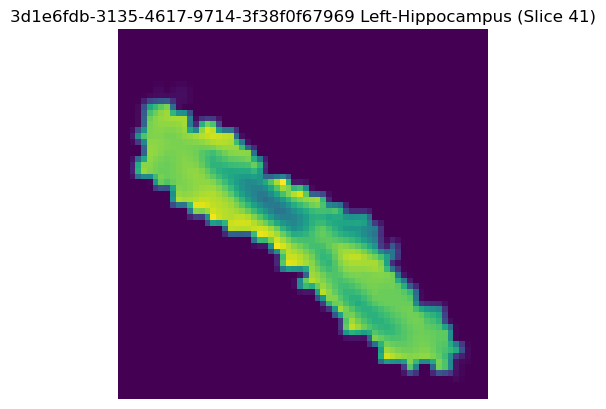

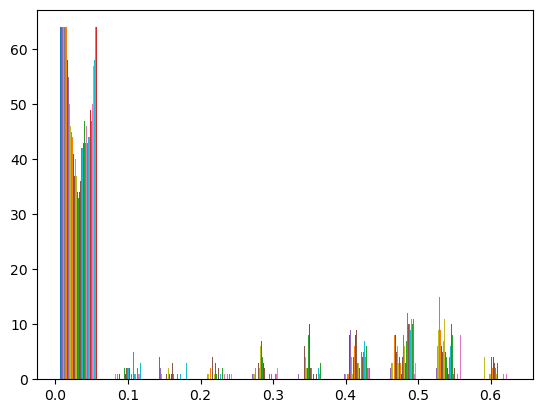

In [17]:
import matplotlib.pyplot as plt
import torch

%matplotlib inline

i_sub = 556
i_str = 12

sample = dataset[i_sub]
struct = sample["image"][i_str, 0]  # [D, H, W]

# Find the z-slice (axial) where the structure has the highest total intensity
z_profile = struct.sum(axis=(1, 2))  # Sum over H and W → shape: [D]
z_max = torch.argmax(z_profile).item()

# Plot that slice
plt.imshow(struct[z_max].cpu())
plt.title(f"{sample['GUID'][i_str]} {sample['struct_name'][i_str]} (Slice {z_max})")
plt.axis('off')
plt.show()

metadata.query(f"GUID == '{sample['GUID'][i_str]}'")[["subject"]].values[0,0]

plt.hist(struct[z_max].cpu())
plt.show()


In [8]:
import numpy as np

npz_data = np.load("/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/region_brain/batched_adni/batch_0001.npz")
mus = np.array(npz_data["mus"])
guids = np.array(npz_data["GUID"])
label_name = np.array(npz_data["LabelName"])


In [2]:
!ls /mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/region_brain/batched_adni


batch_0001.npz	batch_0006.npz	batch_0011.npz	batch_0016.npz	batch_0021.npz
batch_0002.npz	batch_0007.npz	batch_0012.npz	batch_0017.npz	batch_0022.npz
batch_0003.npz	batch_0008.npz	batch_0013.npz	batch_0018.npz
batch_0004.npz	batch_0009.npz	batch_0014.npz	batch_0019.npz
batch_0005.npz	batch_0010.npz	batch_0015.npz	batch_0020.npz


In [6]:
mus.shape

(988, 113, 8, 8, 8, 8)

In [10]:
label_name.shape

(1, 113)

In [11]:
1000*22

22000

In [42]:
import numpy as np

# # Path to your .npz file
file_path = batch_files[0]

# Load the file
data = np.load(file_path)

# Show keys available in the file
print("Keys:", data.files)

Keys: ['images', 'segmentations', 'GUID']


In [44]:
data['GUID'][0:5]

array(['I450385', 'I164108', 'I473670', 'I132891', 'I241030'], dtype='<U8')